# Frequency Analysis

Using polars to do basic corpus searching


In [1]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import matplotlib.pyplot as plt

pl.Config.set_float_precision(2)

polars.config.Config

In [3]:
c = pl.read_parquet("brown.parquet")
c.head(10)

token,tag,sentence_tag,file_id,category
str,str,str,str,str
"""The""","""AT""","""B""","""ca01""","""news"""
"""Fulton""","""NP-TL""","""I""","""ca01""","""news"""
"""County""","""NN-TL""","""I""","""ca01""","""news"""
"""Grand""","""JJ-TL""","""I""","""ca01""","""news"""
"""Jury""","""NN-TL""","""I""","""ca01""","""news"""
"""said""","""VBD""","""I""","""ca01""","""news"""
"""Friday""","""NR""","""I""","""ca01""","""news"""
"""an""","""AT""","""I""","""ca01""","""news"""
"""investigation""","""NN""","""I""","""ca01""","""news"""


## Token frequency

### Absolute frequency

In [4]:
abs_freq = c["token"].value_counts(sort=True)
abs_freq.head()

token,count
str,u32
"""the""",62713
""",""",58334
""".""",49346
"""of""",36080
"""and""",27915


### Relative frequency

In [5]:
rel_freq = (
    c["token"]
    .value_counts(normalize=True, sort=True)
    .with_columns(pl.col("proportion") * 100000)
)
rel_freq.head()

token,proportion
str,f64
"""the""",5400.74
""",""",5023.63
""".""",4249.60
"""of""",3107.15
"""and""",2404.00


### Zipf's Law

<Axes: xlabel='rank', ylabel='count'>

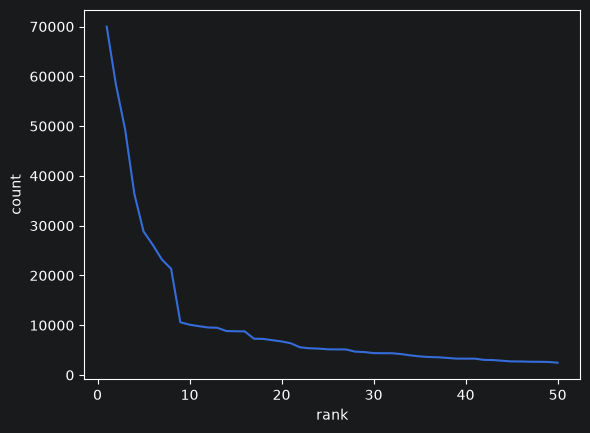

In [6]:
zipf = (
    c["token"]
    .str.to_lowercase()
    .value_counts(sort=True)
    .with_row_index("rank", offset=1)
)
sns.lineplot(data=zipf.head(50), x="rank", y="count")

<Axes: xlabel='rank', ylabel='count'>

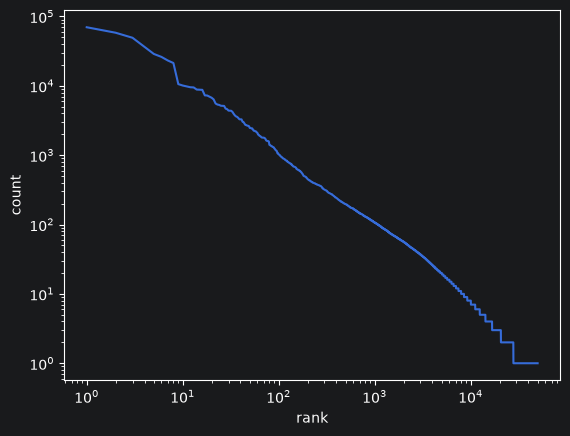

In [7]:
plt.loglog()
sns.lineplot(data=zipf, x="rank", y="count")

## Dispersion

### Range

$$\mbox{range}=\mbox{no. of parts with word $w$}$$

$$\mbox{range}\%=\frac{\mbox{no. of parts with word $w$}}{\mbox{total no. of parts in the corpus}}\times 100$$

In [10]:
n_file_ids = c.select(pl.col("file_id").n_unique()).item()
r2 = (
    c.group_by(pl.col("token").str.to_lowercase())
    .agg((pl.col("file_id").n_unique() / n_file_ids * 100).alias("r2"))
    .sort(by="r2", descending=True)
)
r2.head(10)

token,r2
str,f64
"""and""",100.00
"""from""",100.00
"""for""",100.00
"""of""",100.00
"""on""",100.00
"""at""",100.00
"""in""",100.00
"""it""",100.00
"""that""",100.00


### Standard deviation

In [79]:
std_dev = c.group_by('file_id').agg(pl.col('token').value_counts(normalize=True).alias('c')) \
    .explode('c') \
    .select(pl.col("c").struct.unnest()) \
    .with_columns(pl.col('proportion') * 100000) \
    .group_by('token') \
    .agg((pl.col('proportion').sum()**2).alias('s1'),
        (pl.col('proportion')**2).sum().alias('s2')) \
    .with_columns(((n_file_ids*pl.col('s2')-pl.col('s1')).sqrt()/n_file_ids).alias('sigma')) \
   .sort(by='sigma', descending=True)

    #.with_columns((pl.col('s2')-pl.col('s1')).sqrt().alias('sigma')) \
#    .sort(by='sigma', descending=False)

std_dev.head(10)

token,s1,s2,sigma
str,f64,f64,f64
"""the""",7353885688303.53,15674729933.42,1390.65
""",""",6258515136135.10,13280452320.08,1235.66
"""of""",2443096600764.28,5596293758.68,1191.72
""".""",4483578028942.48,9632621688.62,1153.66
"""I""",47787950138.80,361852521.79,729.76
"""is""",189109958848.17,630581400.38,710.44
"""and""",1444818137504.59,3128804925.34,691.62
"""was""",175260054708.28,565771478.42,656.13
"""''""",137985201533.72,486803439.46,649.36


### Coefficient of variation

In [82]:
cv = c.group_by('file_id').agg(pl.col('token').value_counts(normalize=True).alias('c')) \
    .explode('c') \
    .select(pl.col("c").struct.unnest()) \
    .with_columns(pl.col('proportion') * 100000) \
    .group_by('token') \
    .agg(pl.col('proportion').mean().alias('mean')) \
    .join(std_dev, on='token') \
    .with_columns((pl.col('sigma')/pl.col('mean')).alias('cv')) \
    .sort(by='cv', descending=True)
cv

token,mean,s1,s2,sigma,cv
str,f64,f64,f64,f64,f64
"""form""",90.43,236341467.98,6808686.88,112.57,1.24
"""lines""",78.60,72066831.16,4261487.25,90.75,1.15
"""state""",143.10,564245407.52,14323709.62,162.45,1.14
"""(""",300.07,10841726760.82,77042951.32,332.74,1.11
"""I""",658.45,47787950138.80,361852521.79,729.76,1.11
…,…,…,…,…,…
"""cowbirds'""",39.62,1569.72,1569.72,1.77,0.04
"""muddling""",39.62,1569.72,1569.72,1.77,0.04
"""ramming""",39.62,1569.72,1569.72,1.77,0.04


### Juliand's *D*

### DP (Deviation of Proportions)

Brezina pg. 26

In [ ]:
the = (
    bnc.filter(mode="spoken")
    .group_by("file_id")
    .agg(
        (
            pl.col("lemma").len().alias("n"),
            (pl.col("lemma") == "the").sum().alias("the"),
            (pl.col("lemma") == "i").sum().alias("i"),
            (pl.col("lemma") == "you").sum().alias("you"),
        )
    )
    .select("file_id", (cs.numeric().exclude("n") / pl.col("n") * 10000))
    .sort(by="file_id")
)

the.head(10)

In [ ]:
sns.histplot(the.to_pandas(), y="the")

In [ ]:
sns.lmplot(
    the.to_pandas(),
    x="the",
    y="i",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"},
)

In [ ]:
sns.pairplot(
    the.to_pandas(),
    vars=["the", "i", "you"],
    kind="reg",
    corner=True,
    plot_kws={"scatter_kws": {"alpha": 0.1}, "line_kws": {"color": "red"}},
)

In [ ]:
hits = bnc.filter(
    pl.col("lemma").is_in(["very", "really", "rather", "quite"]), pl.col("tag") == "AV0"
)
counts = (
    hits.group_by("lemma", "text_type")
    .agg(pl.len().alias("count"))
    .with_columns(
        (pl.col("count") / pl.col("count").sum().over("text_type") * 100).alias("pct")
    )
)
counts

In [ ]:
hits = bnc.filter(pl.col("lemma").is_in(["very", "really"]))

ratio = (
    hits.group_by("text_type")
    .agg(
        ((pl.col("token") == "very").sum() / (pl.col("token") == "really").sum()).alias(
            "ratio"
        )
    )
    .sort(by="ratio")
)
ratio